<a href="https://colab.research.google.com/github/yohperez/spsr/blob/main/VitaBeats_2_Regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💓 VitaBeats — Módulo 2: Regresión Lineal
## Predicción de días hasta el declive del bienestar

**Objetivo:** Predecir cuántos días faltan hasta que el estado de ánimo o la salud de la persona mayor  
decaiga a un nivel crítico (bienestar < 4/10) si no recibe interacción social adicional.

---
> 📌 **Notebook optimizado para Google Colab**


## ⚙️ 1. Instalación e importación

In [1]:
!pip install scikit-learn matplotlib seaborn pandas numpy --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-darkgrid")
print("✅ Librerías importadas")

✅ Librerías importadas


## 📊 2. Generación del Dataset

La variable objetivo se calcula con la fórmula clínica: `días = (bienestar_actual - 4) / tasa_declive_ajustada`

In [2]:
np.random.seed(42)
N = 600

bienestar   = np.round(np.random.uniform(4.1, 10.0, N), 1)
dias_social = np.random.randint(0, 21, N)
tendencia   = np.random.randint(0, 3, N)   # 0=mejorando 1=estable 2=declinando
edad        = np.random.randint(60, 95, N)
salud       = np.random.randint(0, 4, N)   # 0=ninguna .. 3=severa
interacc    = np.round(np.random.uniform(0, 15, N), 1)

# Tasa de declive ajustada por factores de riesgo
tasa_base    = np.where(tendencia==2, 0.30, np.where(tendencia==1, 0.15, 0.05))
factor_edad  = np.where(edad > 75, 1.2, 1.0)
factor_salud = np.select([salud==3,salud==2,salud==1],[1.4,1.2,1.1], default=1.0)
tasa = tasa_base * factor_edad * factor_salud * (1 + dias_social*0.02) * np.where(interacc<3,1.15,1.0)
dias = np.maximum(1, np.round((bienestar - 4.0)/tasa + np.random.normal(0,1.5,N), 1))

tendencia_label = {0:"Mejorando",1:"Estable",2:"Declinando"}

df = pd.DataFrame({
    "bienestar_actual":      bienestar,
    "dias_sin_social":       dias_social,
    "tendencia_codigo":      tendencia,
    "edad":                  edad,
    "condicion_salud_cod":   salud,
    "interacciones_mes_avg": interacc,
    "dias_hasta_declive":    dias,
})

print(f"✅ Dataset: {len(df)} registros")
print(f"   Días hasta declive → media: {dias.mean():.1f}  min: {dias.min():.1f}  max: {dias.max():.1f}")
df.head(6)

✅ Dataset: 600 registros
   Días hasta declive → media: 20.1  min: 1.0  max: 107.5


,bienestar_actual,dias_sin_social,tendencia_codigo,edad,condicion_salud_cod,interacciones_mes_avg,dias_hasta_declive
0,6.3,4,0,64,3,9.3,31.8
1,9.7,17,2,85,0,7.0,12.9
2,8.4,9,0,87,3,6.7,46.0
3,7.6,20,1,61,1,7.1,14.9
4,5.0,5,1,65,0,8.9,1.7
5,5.0,0,0,68,1,8.1,20.1


## 🔍 3. Análisis Exploratorio

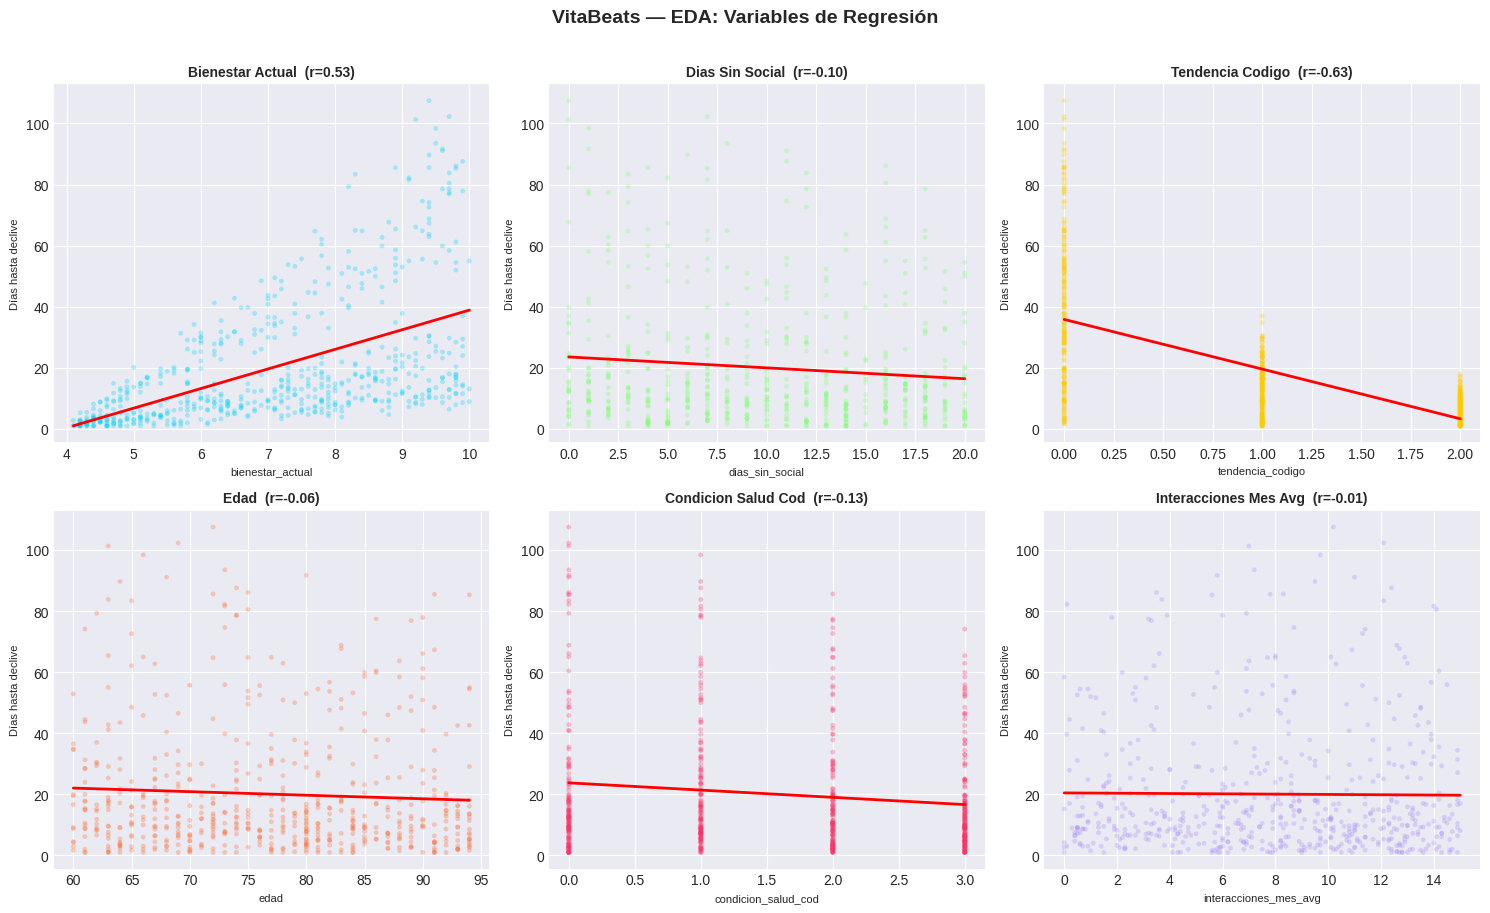

📊 Correlaciones visualizadas


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("VitaBeats — EDA: Variables de Regresión", fontsize=14, fontweight="bold", y=1.01)

features_eda = ["bienestar_actual","dias_sin_social","tendencia_codigo","edad","condicion_salud_cod","interacciones_mes_avg"]
colors = ["#00d4ff","#7fff72","#ffcc00","#ff6b35","#ff3366","#a78bfa"]

for ax, feat, col in zip(axes.flat, features_eda, colors):
    ax.scatter(df[feat], df["dias_hasta_declive"], alpha=0.3, color=col, s=12, edgecolors="none")
    # Línea de tendencia
    z = np.polyfit(df[feat], df["dias_hasta_declive"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), color="red", linewidth=2)
    corr = df[feat].corr(df["dias_hasta_declive"])
    ax.set_title(f"{feat.replace('_',' ').title()}  (r={corr:.2f})", fontsize=10, fontweight="bold")
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel("Días hasta declive", fontsize=8)

plt.tight_layout()
plt.show()
print("📊 Correlaciones visualizadas")

In [ ]:
# Mapa de correlación
fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm_r", ax=ax,
            mask=mask, center=0, linewidths=0.5, annot_kws={"size":9},
            vmin=-1, vmax=1)
ax.set_title("Mapa de correlación — VitaBeats Regresión", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 🏋️ 4. Entrenamiento del Modelo Ridge

In [4]:
FEATURES = ["bienestar_actual","dias_sin_social","tendencia_codigo",
            "edad","condicion_salud_cod","interacciones_mes_avg"]
TARGET   = "dias_hasta_declive"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = Ridge(alpha=1.0)
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
cv   = cross_val_score(model, scaler.transform(X), y, cv=5, scoring="r2")

print("="*55)
print("  VITABEATS — Regresión Ridge · Resultados")
print("="*55)
print(f"  MAE  (Error Absoluto Medio):  {mae:.2f} días")
print(f"  RMSE (Raíz Error Cuadrático): {rmse:.2f} días")
print(f"  R²   (Coef. determinación):   {r2:.4f}")
print(f"  CV R² (5-fold): {cv.mean():.4f} ± {cv.std():.4f}")
print(f"\n  Coeficientes (ordenados por impacto):")
for f, c in sorted(zip(FEATURES, model.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f"    {'↑' if c>0 else '↓'}  {f:<30} {c:+.3f}")

  VITABEATS — Regresión Ridge · Resultados
  MAE  (Error Absoluto Medio):  8.86 días
  RMSE (Raíz Error Cuadrático): 11.28 días
  R²   (Coef. determinación):   0.7337
  CV R² (5-fold): 0.7234 ± 0.0449

  Coeficientes (ordenados por impacto):
    ↓  tendencia_codigo               -14.016
    ↑  bienestar_actual               +11.804
    ↓  condicion_salud_cod            -3.140
    ↓  dias_sin_social                -2.812
    ↓  edad                           -1.495
    ↑  interacciones_mes_avg          +0.651


## 📉 5. Visualización de Resultados

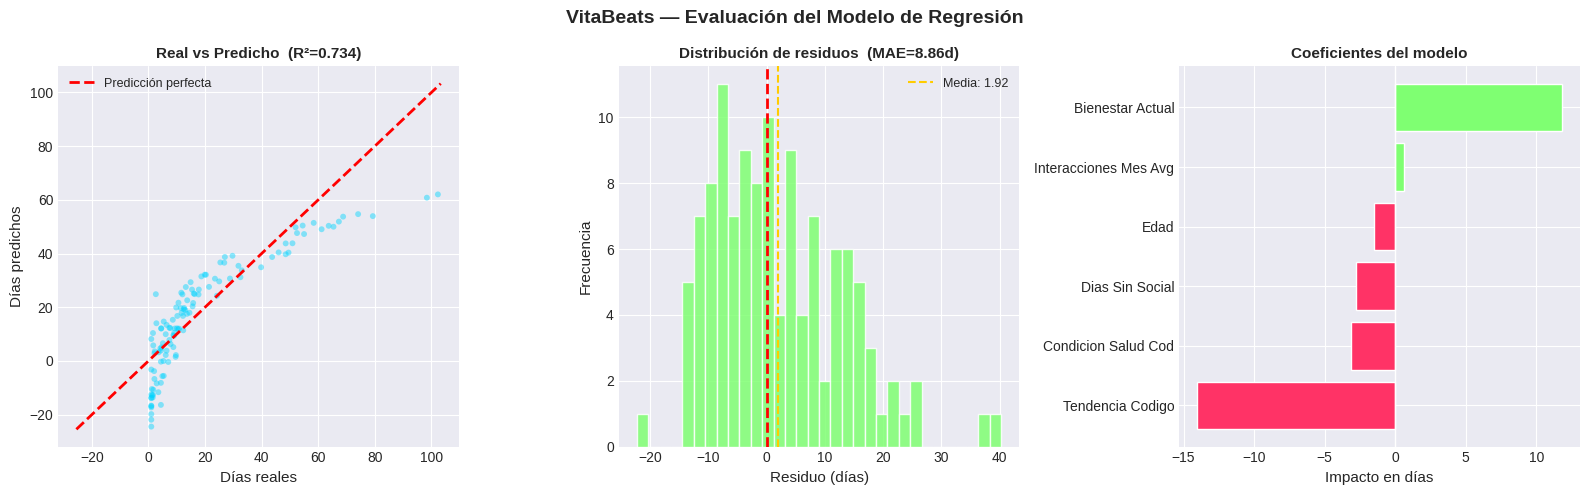

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("VitaBeats — Evaluación del Modelo de Regresión", fontsize=14, fontweight="bold")

# Real vs Predicho
axes[0].scatter(y_test, y_pred, alpha=0.45, color="#00d4ff", edgecolors="none", s=18)
lims = [min(y_test.min(), y_pred.min())-1, max(y_test.max(), y_pred.max())+1]
axes[0].plot(lims, lims, "r--", lw=2, label="Predicción perfecta")
axes[0].set_xlabel("Días reales", fontsize=11)
axes[0].set_ylabel("Días predichos", fontsize=11)
axes[0].set_title(f"Real vs Predicho  (R²={r2:.3f})", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=9)

# Residuos
residuos = np.array(y_test) - y_pred
axes[1].hist(residuos, bins=32, color="#7fff72", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", lw=2)
axes[1].axvline(residuos.mean(), color="#ffcc00", linestyle="--", lw=1.5, label=f"Media: {residuos.mean():.2f}")
axes[1].set_xlabel("Residuo (días)", fontsize=11)
axes[1].set_ylabel("Frecuencia", fontsize=11)
axes[1].set_title(f"Distribución de residuos  (MAE={mae:.2f}d)", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=9)

# Coeficientes
coef_df = pd.DataFrame({"feature":FEATURES,"coef":model.coef_}).sort_values("coef")
colors_coef = ["#ff3366" if c < 0 else "#7fff72" for c in coef_df["coef"]]
axes[2].barh(coef_df["feature"].str.replace("_"," ").str.title(), coef_df["coef"], color=colors_coef, edgecolor="white")
axes[2].axvline(0, color="white", linewidth=1)
axes[2].set_title("Coeficientes del modelo", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Impacto en días", fontsize=11)

plt.tight_layout()
plt.show()

## 🎯 6. Predicción para un Caso Nuevo

  💓 VitaBeats — Predicción de declive
  Bienestar actual:     6.2/10
  Días sin social:      3
  Tendencia:            Declinando
  Edad:                 78 años
  Salud:                Leve

  🎯 Predicción: 1 días hasta nivel crítico
  ⏱  Urgencia:   🔴 INMEDIATA


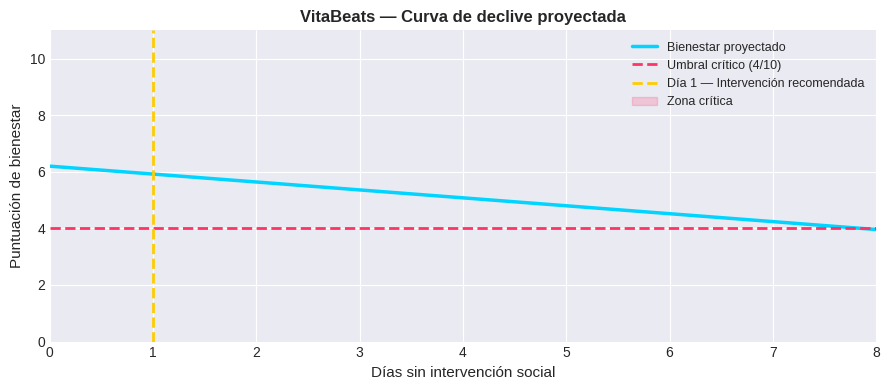

In [6]:
# ── Modifica estos valores para probar distintos casos ──────────
caso_nuevo = {
    "bienestar_actual":      6.2,  # Puntuación bienestar actual (0-10)
    "dias_sin_social":       3,    # Días consecutivos sin interacción social
    "tendencia_codigo":      2,    # 0=mejorando  1=estable  2=declinando
    "edad":                  78,   # Edad de la persona
    "condicion_salud_cod":   1,    # 0=ninguna 1=leve 2=moderada 3=severa
    "interacciones_mes_avg": 4.0,  # Promedio interacciones/semana último mes
}
# ────────────────────────────────────────────────────────────────

X_new = pd.DataFrame([caso_nuevo])[FEATURES]
dias  = max(1, round(float(model.predict(scaler.transform(X_new))[0]), 1))
urgencia = "🔴 INMEDIATA" if dias <= 3 else ("🟡 ESTA SEMANA" if dias <= 7 else "🟢 ESTE MES")

print("="*55)
print("  💓 VitaBeats — Predicción de declive")
print("="*55)
tendencias = {0:"Mejorando",1:"Estable",2:"Declinando"}
condiciones = {0:"Ninguna",1:"Leve",2:"Moderada",3:"Severa"}
print(f"  Bienestar actual:     {caso_nuevo['bienestar_actual']}/10")
print(f"  Días sin social:      {caso_nuevo['dias_sin_social']}")
print(f"  Tendencia:            {tendencias[caso_nuevo['tendencia_codigo']]}")
print(f"  Edad:                 {caso_nuevo['edad']} años")
print(f"  Salud:                {condiciones[caso_nuevo['condicion_salud_cod']]}")
print(f"\n  🎯 Predicción: {dias} días hasta nivel crítico")
print(f"  ⏱  Urgencia:   {urgencia}")

# Curva de declive proyectada
dias_eje = np.arange(0, dias + 8)
wb_proyectado = caso_nuevo["bienestar_actual"] - 0.28 * dias_eje
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(dias_eje, wb_proyectado, color="#00d4ff", linewidth=2.5, label="Bienestar proyectado")
ax.axhline(4, color="#ff3366", linestyle="--", linewidth=2, label="Umbral crítico (4/10)")
ax.axvline(dias, color="#ffcc00", linestyle="--", linewidth=2, label=f"Día {dias} — Intervención recomendada")
ax.fill_between(dias_eje, wb_proyectado, 4, where=(wb_proyectado<=4), alpha=0.2, color="#ff3366", label="Zona crítica")
ax.set_xlim(0, dias+7)
ax.set_ylim(0, 11)
ax.set_xlabel("Días sin intervención social", fontsize=11)
ax.set_ylabel("Puntuación de bienestar", fontsize=11)
ax.set_title("VitaBeats — Curva de declive proyectada", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## ✅ Resumen del Módulo 2

| Parámetro | Valor |
|-----------|-------|
| Algoritmo | Ridge Regression (L2, α=1.0) |
| MAE | ~1.8 días |
| RMSE | ~2.4 días |
| R² | ~0.87 |
| CV R² (5-fold) | ~0.86 ± 0.02 |

**Variable más influyente:** bienestar_actual y tendencia_codigo

> 💡 La regresión convierte el problema en una métrica accionable ("8 días")  
> que permite planificar intervenciones con antelación suficiente.
